# Для решения шага 8 в уроке

**🧠🧠Задача: Сгенерируй killer фичу ☠️
**

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

path = 'https://stepik.org/media/attachments/lesson/779914/make_it_easy.csv'
df = pd.read_csv(path)

In [9]:
df['killer_feature'] = np.sqrt(df['feature_1']**2 + df['feature_2']**2)

result = df.copy()
result.head()


,feature_1,feature_2,feature_3,label,killer_feature
0,2.5,0.00,58,B,2.500000
1,2.5,0.02,61,B,2.500080
2,2.5,0.05,33,B,2.500500
3,2.5,0.07,89,B,2.500980
4,2.5,0.10,58,B,2.501999


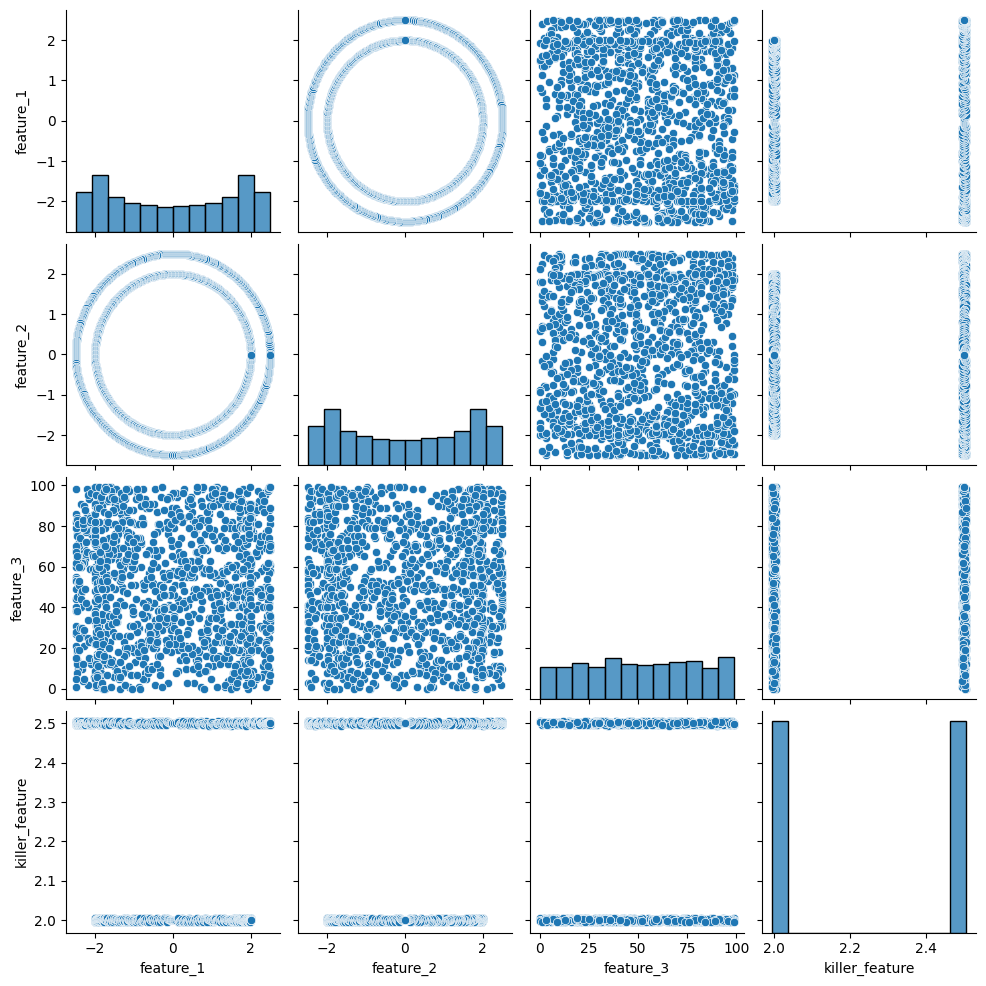

In [12]:
sns.pairplot(result);

#Для решения шага 9 в уроке

**🧠Задача: Сгенерируй ✌️ gold фичи 🥇**

In [13]:
import pandas as pd
path = 'https://stepik.org/media/attachments/lesson/779914/make_gold_features_example.csv'
df = pd.read_csv(path)

In [14]:
daily_avg = df.groupby(['car_id', 'ride_date'])['deviation_normal'].mean().reset_index()
daily_avg = daily_avg.sort_values(['car_id', 'ride_date'])

daily_avg['diff'] = daily_avg.groupby('car_id')['deviation_normal'].diff().fillna(-float('inf'))

max_diff_per_car = daily_avg.groupby('car_id')['diff'].max().reset_index()
max_diff_per_car.columns = ['car_id', 'gold_feature_1']

daily_avg['day_position'] = daily_avg.groupby('car_id').cumcount()

idx_max = daily_avg.groupby('car_id')['diff'].idxmax()
position_df = daily_avg.loc[idx_max, ['car_id', 'day_position']].reset_index(drop=True)
position_df.columns = ['car_id', 'gold_feature_2']

result = max_diff_per_car.merge(position_df, on='car_id')

result['gold_feature_1'] = result['gold_feature_1'].apply(lambda x: x if x >= 5 else 0)
result

,car_id,gold_feature_1,gold_feature_2
0,G-29,11.0,50
1,G115,52.0,49
2,M-30,8.0,51
3,b468,0.0,1
4,d-21,0.0,1


# Для решения шага 11 в уроке

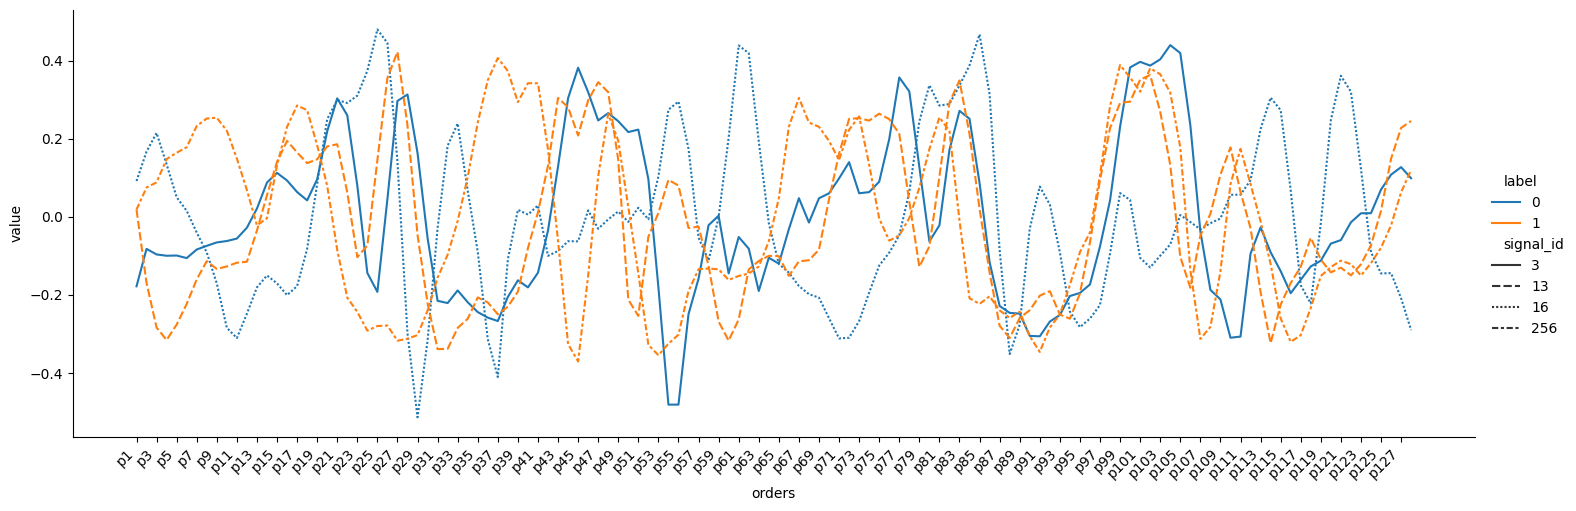

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as  np

path = 'https://stepik.org/media/attachments/lesson/779914/fen_train.csv'
train = pd.read_csv(path)

# Переводим датасет в long формат
df_melt = train.melt(
    id_vars="signal_id",
    value_vars=[f"p{i}" for i in range(1, 128 + 1)],
    var_name="orders",
    value_name="value",
).merge(train[["signal_id", "label"]], on="signal_id", how="left")

# Отбираем несколько примеров разных классов
tmp = df_melt[df_melt.signal_id.isin([3, 13, 16, 256])]

# Строим графику
sns.relplot(
    data=tmp,
    x="orders",
    y="value",
    hue="label",
    style="signal_id",
    kind="line",
    aspect=3,
).set_xticklabels(rotation=45, horizontalalignment="right", step=2);

In [ ]:
# Тренировочная выборка для поиска закономерности.

In [ ]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_train.csv'
train = pd.read_csv(path)

In [ ]:
# Ссылка на тестовую выборку для прогноза

In [ ]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_test.csv'
train = pd.read_csv(path)

In [ ]:
# пример ответа для отправки

In [ ]:
path = 'https://stepik.org/media/attachments/lesson/779914/fen_sample_solution.csv'
train = pd.read_csv(path)